# Fake Job Posting Detection

**Goal:** Build a machine learning system that flags fraudulent job postings using both
the free-text fields (title, company profile, description, requirements, benefits) and
the structured/meta fields (employment type, experience level, education, industry,
telecommuting flag, logo flag, screening-questions flag, etc.).

**Dataset:** Employment Scam Aegean Dataset (EMSCAD), published by the University of the
Aegean's Laboratory of Information & Communication Systems Security. 17,880 real-life job
postings collected 2012–2014, of which 866 (~4.8%) are labeled fraudulent. This is the
same dataset commonly distributed on Kaggle as "Real or Fake Job Posting Prediction".


**Notebook structure**
1. Load & inspect the data
2. Exploratory Data Analysis (EDA)
3. Preprocessing — missing values, text cleaning, feature engineering
4. Train / test split
5. Text vectorization (TF-IDF vs. CountVectorizer)
6. Model building — Logistic Regression, Naive Bayes, Linear SVM, Random Forest
7. Evaluation beyond accuracy (precision, recall, F1, ROC-AUC, PR-AUC, confusion matrices)
8. Comparative analysis & hyperparameter tuning
9. Model interpretation — which words/features drive a "fraud" prediction
10. Final prediction system + limitations


In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, precision_recall_curve, average_precision_score)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)


## 1. Load & Inspect the Data

In [ ]:
df = pd.read_csv("fake_job_postings.csv")
print("Shape:", df.shape)
df.head(3)


Shape: (17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [ ]:
print("Missing values per column:")
missing = df.isnull().sum().sort_values(ascending=False)
pd.DataFrame({"missing_count": missing})


Missing values per column:


,missing_count
salary_range,15012
department,11547
required_education,8105
benefits,7212
required_experience,7050
function,6455
industry,4903
employment_type,3471
company_profile,3308
requirements,2696


fraudulent
0    17014
1      866
Name: count, dtype: int64

Fraud rate: 4.84%


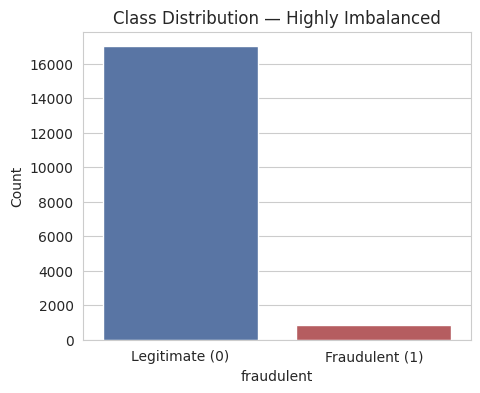

In [ ]:
class_counts = df['fraudulent'].value_counts()
print(class_counts)
print(f"\nFraud rate: {class_counts[1] / len(df) * 100:.2f}%")

plt.figure(figsize=(5,4))
sns.countplot(x='fraudulent', data=df, palette=['#4C72B0', '#C44E52'])
plt.xticks([0,1], ['Legitimate (0)', 'Fraudulent (1)'])
plt.title("Class Distribution — Highly Imbalanced")
plt.ylabel("Count")
plt.show()


## 2. Exploratory Data Analysis

The dataset is heavily imbalanced (~4.8% fraud), which will shape every later decision:
metric choice (never rely on accuracy alone), class weighting, and threshold selection.


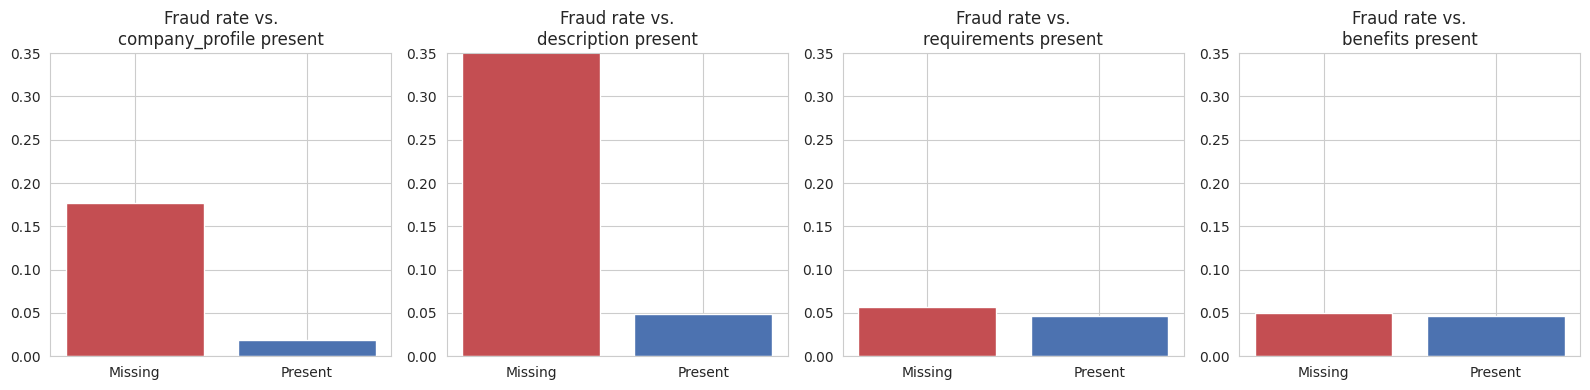

In [ ]:
# Missing structured/text fields as engineered binary signals
text_cols = ['company_profile', 'description', 'requirements', 'benefits']
fig, axes = plt.subplots(1, len(text_cols), figsize=(16,4))
for ax, col in zip(axes, text_cols):
    present = df[col].notnull().astype(int)
    rate = df.groupby(present)['fraudulent'].mean()
    ax.bar(['Missing','Present'], [rate.get(0,0), rate.get(1,0)], color=['#C44E52','#4C72B0'])
    ax.set_title(f"Fraud rate vs.\n{col} present")
    ax.set_ylim(0, 0.35)
plt.tight_layout()
plt.show()


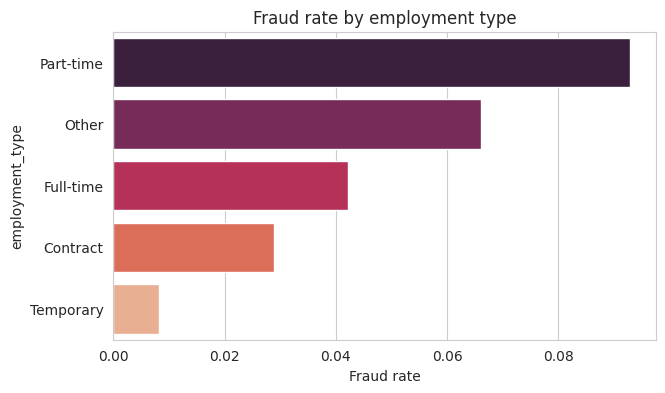

In [ ]:
# Fraud rate by employment type
plt.figure(figsize=(7,4))
rate_by_emp = df.groupby('employment_type')['fraudulent'].mean().sort_values(ascending=False)
sns.barplot(x=rate_by_emp.values, y=rate_by_emp.index, palette='rocket')
plt.xlabel("Fraud rate")
plt.title("Fraud rate by employment type")
plt.show()


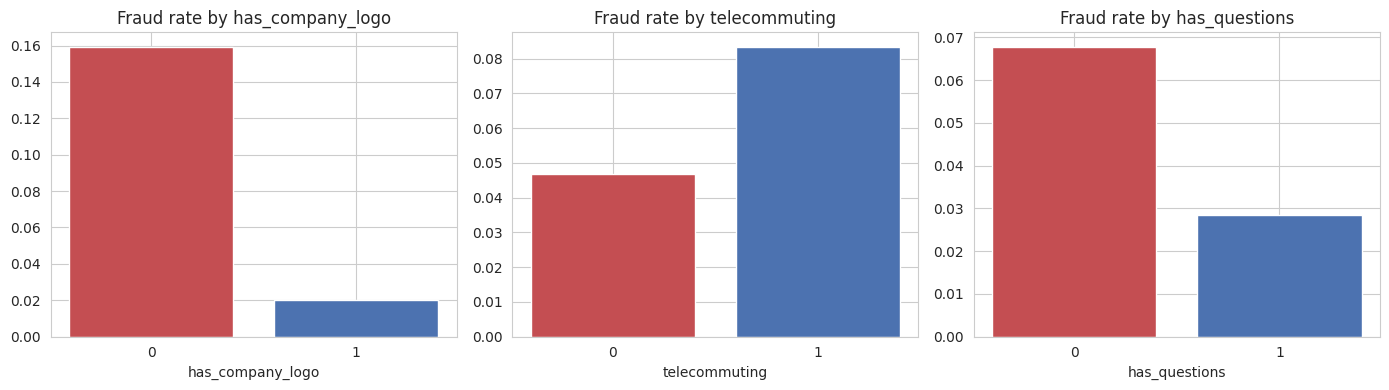

In [ ]:
# Fraud rate by has_company_logo / telecommuting / has_questions
fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax, col in zip(axes, ['has_company_logo', 'telecommuting', 'has_questions']):
    rate = df.groupby(col)['fraudulent'].mean()
    ax.bar(rate.index.astype(str), rate.values, color=['#C44E52','#4C72B0'])
    ax.set_title(f"Fraud rate by {col}")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()


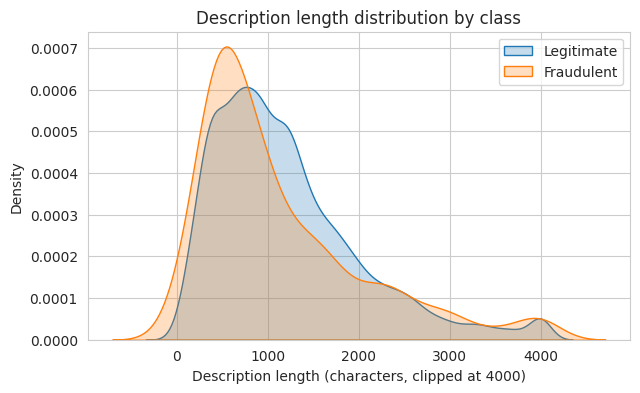

In [ ]:
# Text length distributions
df['description'] = df['description'].fillna('')
df['desc_len'] = df['description'].apply(len)

plt.figure(figsize=(7,4))
sns.kdeplot(df.loc[df.fraudulent==0, 'desc_len'].clip(upper=4000), label='Legitimate', fill=True)
sns.kdeplot(df.loc[df.fraudulent==1, 'desc_len'].clip(upper=4000), label='Fraudulent', fill=True)
plt.title("Description length distribution by class")
plt.xlabel("Description length (characters, clipped at 4000)")
plt.legend()
plt.show()


In [ ]:
# Most common words in fraudulent titles vs legitimate titles (quick look)
from collections import Counter
def top_words(series, n=15):
    words = ' '.join(series.fillna('').str.lower()).split()
    words = [w.strip('.,!?()[]:;"\'') for w in words]
    stop = {'the','and','a','to','of','in','for','is','on','with','an','at','as','&','-','/'}
    words = [w for w in words if w and w not in stop and len(w) > 2]
    return Counter(words).most_common(n)

print("Top words in FRAUDULENT titles:")
print(top_words(df.loc[df.fraudulent==1, 'title']))
print("\nTop words in LEGITIMATE titles:")
print(top_words(df.loc[df.fraudulent==0, 'title']))


Top words in FRAUDULENT titles:
[('entry', 101), ('data', 97), ('engineer', 79), ('assistant', 79), ('home', 69), ('manager', 68), ('payroll', 63), ('customer', 61), ('clerk', 60), ('positions', 58), ('service', 56), ('administrative', 56), ('sales', 49), ('representative', 43), ('position', 39)]

Top words in LEGITIMATE titles:
[('manager', 2129), ('developer', 1775), ('engineer', 1517), ('sales', 1251), ('senior', 943), ('customer', 904), ('service', 830), ('english', 780), ('teacher', 775), ('marketing', 753), ('abroad', 692), ('associate', 646), ('software', 626), ('assistant', 589), ('designer', 585)]


## 3. Preprocessing

Steps:
1. **Missing values** — text fields: fill with empty string (absence is itself informative,
   captured separately as a binary "is_missing" indicator). Categorical fields: fill with
   `"Unspecified"`.
2. **Text cleaning** — lowercase, strip HTML tags/URLs, remove punctuation/digits, collapse
   whitespace. (Kept lightweight — no aggressive stemming — since TF-IDF on raw-ish tokens
   already performs well for this kind of scam-language detection and heavy stemming can
   destroy useful signal like company names or "$$$".)
3. **Feature engineering**
   - Combine all free-text fields into one `full_text` field for vectorization.
   - Binary "missing indicator" features for company_profile/requirements/benefits/salary_range.
   - Keep the three native binary flags (`telecommuting`, `has_company_logo`, `has_questions`).
   - One-hot encode low-cardinality categoricals (`employment_type`, `required_experience`,
     `required_education`).


In [ ]:
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = str(text)
    text = re.sub(r'<[^>]+>', ' ', text)          # strip HTML tags
    text = re.sub(r'http\S+|www\.\S+', ' ', text)  # strip URLs
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)          # keep letters only
    text = re.sub(r'\s+', ' ', text).strip()
    return text

text_fields = ['title', 'company_profile', 'description', 'requirements', 'benefits']
for col in text_fields:
    df[col] = df[col].fillna('')

df['full_text_raw'] = df[text_fields].agg(' '.join, axis=1)
df['full_text'] = df['full_text_raw'].apply(clean_text)
df['text_len'] = df['full_text'].apply(len)
df['word_count'] = df['full_text'].apply(lambda t: len(t.split()))

df[['title','full_text']].head(2)


,title,full_text
0,Marketing Intern,marketing intern we re food and we ve created ...
1,Customer Service - Cloud Video Production,customer service cloud video production second...


In [ ]:
# Missing-field indicators (missingness itself can be a fraud signal)
for col in ['company_profile', 'requirements', 'benefits', 'salary_range']:
    df[f'{col}_missing'] = df[col].isnull().astype(int) if col == 'salary_range' else (df[col].str.len() == 0).astype(int)

cat_cols = ['employment_type', 'required_experience', 'required_education']
for col in cat_cols:
    df[col] = df[col].fillna('Unspecified')

df[['company_profile_missing','requirements_missing','benefits_missing','salary_range_missing']].mean()


,0
company_profile_missing,0.185011
requirements_missing,0.150783
benefits_missing,0.403356
salary_range_missing,0.839597


## 4. Train / Test Split

In [ ]:
feature_cols_struct = ['telecommuting', 'has_company_logo', 'has_questions',
                       'company_profile_missing', 'requirements_missing',
                       'benefits_missing', 'salary_range_missing',
                       'text_len', 'word_count'] + cat_cols

X = df[['full_text'] + feature_cols_struct]
y = df['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train fraud rate: %.2f%%  Test fraud rate: %.2f%%" %
      (y_train.mean()*100, y_test.mean()*100))


Train shape: (14304, 13)  Test shape: (3576, 13)
Train fraud rate: 4.84%  Test fraud rate: 4.84%


## 5. Text Vectorization

We compare **TF-IDF** and **CountVectorizer** on the combined free-text field, both with
English stop-word removal, unigrams+bigrams, and a vocabulary cap to control dimensionality.
TF-IDF down-weights very common words (e.g. "job", "work") and up-weights words that are
distinctive of a particular posting, which is generally the stronger representation for
this kind of task — we verify that empirically below rather than assuming it.


In [ ]:
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2), stop_words='english',
                         min_df=3, sublinear_tf=True)
count_vec = CountVectorizer(max_features=8000, ngram_range=(1,2), stop_words='english',
                             min_df=3)

X_train_tfidf = tfidf.fit_transform(X_train['full_text'])
X_test_tfidf = tfidf.transform(X_test['full_text'])

X_train_count = count_vec.fit_transform(X_train['full_text'])
X_test_count = count_vec.transform(X_test['full_text'])

print("TF-IDF matrix shape:", X_train_tfidf.shape)


TF-IDF matrix shape: (14304, 8000)


In [ ]:
# Structured / numeric side of the pipeline: one-hot + scale
from scipy.sparse import hstack, csr_matrix

struct_train = pd.get_dummies(X_train[feature_cols_struct], columns=cat_cols)
struct_test = pd.get_dummies(X_test[feature_cols_struct], columns=cat_cols)
struct_test = struct_test.reindex(columns=struct_train.columns, fill_value=0)

scaler = MinMaxScaler()  # keeps structured features non-negative so MultinomialNB can run on the combined matrix too
struct_train_scaled = scaler.fit_transform(struct_train)
struct_test_scaled = scaler.transform(struct_test)

# Combined feature matrix: TF-IDF text + scaled structured features
X_train_combined = hstack([X_train_tfidf, csr_matrix(struct_train_scaled)]).tocsr()
X_test_combined = hstack([X_test_tfidf, csr_matrix(struct_test_scaled)]).tocsr()

print("Combined (text + structured) train shape:", X_train_combined.shape)


Combined (text + structured) train shape: (14304, 8036)


## 6. Model Building

We train four classifiers, each on the **combined** (text + structured) TF-IDF feature
matrix, since EDA showed structured features (missing company profile, employment type,
missing logo) carry real signal on top of the text:

- **Logistic Regression** (`class_weight='balanced'`) — strong, interpretable linear baseline
- **Multinomial Naive Bayes** — classic text-classification baseline (fast, probabilistic)
- **Linear SVM** — often strong on high-dimensional sparse TF-IDF data
- **Random Forest** — non-linear model, to see if it can exploit structured-feature interactions

`class_weight='balanced'` (or equivalent) is used wherever available to counter the ~19:1
imbalance, since a naive model can score 95%+ "accuracy" by predicting everything as
legitimate.


In [ ]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, needs_dense=False):
    Xtr = X_tr.toarray() if needs_dense else X_tr
    Xte = X_te.toarray() if needs_dense else X_te
    model.fit(Xtr, y_tr)
    y_pred = model.predict(Xte)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(Xte)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(Xte)
    else:
        y_score = y_pred

    results = {
        'model': name,
        'accuracy': accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred),
        'recall': recall_score(y_te, y_pred),
        'f1': f1_score(y_te, y_pred),
        'roc_auc': roc_auc_score(y_te, y_score),
        'pr_auc': average_precision_score(y_te, y_score),
    }
    cm = confusion_matrix(y_te, y_pred)
    return model, results, cm, y_pred, y_score

models_to_run = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced',
                                               random_state=RANDOM_STATE),
    'Multinomial Naive Bayes': MultinomialNB(),   # note: MNB needs non-negative features (TF-IDF is)
    'Linear SVM': LinearSVC(class_weight='balanced', random_state=RANDOM_STATE, max_iter=5000),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                             random_state=RANDOM_STATE, n_jobs=-1),
}

all_results = []
fitted_models = {}
confusion_mats = {}
scores_store = {}

for name, mdl in models_to_run.items():
    fitted, res, cm, y_pred, y_score = evaluate_model(name, mdl, X_train_combined, y_train,
                                                       X_test_combined, y_test)
    fitted_models[name] = fitted
    all_results.append(res)
    confusion_mats[name] = cm
    scores_store[name] = (y_pred, y_score)
    print(f"Done: {name}")

results_df = pd.DataFrame(all_results).set_index('model').round(4)
results_df


Done: Logistic Regression
Done: Multinomial Naive Bayes
Done: Linear SVM
Done: Random Forest


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Logistic Regression,0.9622,0.5688,0.9075,0.6993,0.9910,0.9032
Multinomial Naive Bayes,0.9645,0.7805,0.3699,0.5020,0.9381,0.6229
Linear SVM,0.9883,0.8876,0.8671,0.8772,0.9919,0.9440
Random Forest,0.9796,1.0000,0.5780,0.7326,0.9915,0.9136


## 7. Evaluation Beyond Accuracy

Because only ~4.8% of postings are fraudulent, accuracy alone is misleading — a model that
predicts "legitimate" for everything scores ~95.2% accuracy while catching zero fraud. We
therefore look at **precision**, **recall**, **F1**, **ROC-AUC**, **PR-AUC**, and confusion
matrices together, since in this problem missing a fraudulent posting (false negative) and
wrongly flagging a legitimate one (false positive) carry different real-world costs.


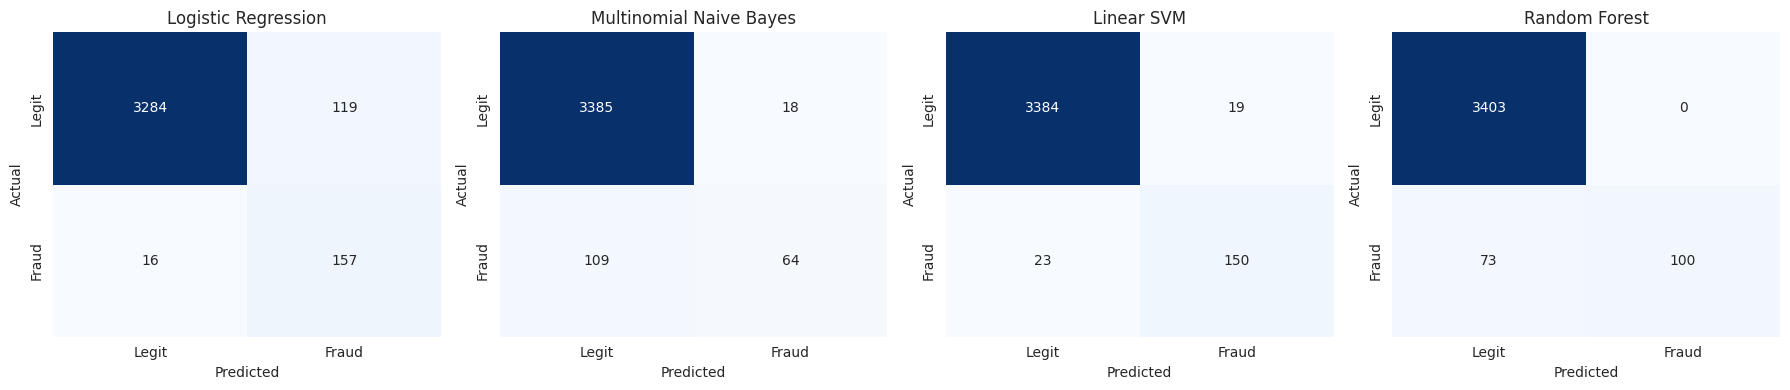

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, (name, cm) in zip(axes, confusion_mats.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


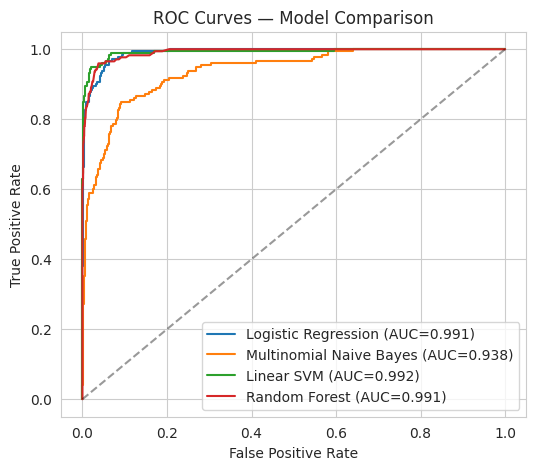

In [ ]:
plt.figure(figsize=(6,5))
for name, (y_pred, y_score) in scores_store.items():
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.show()


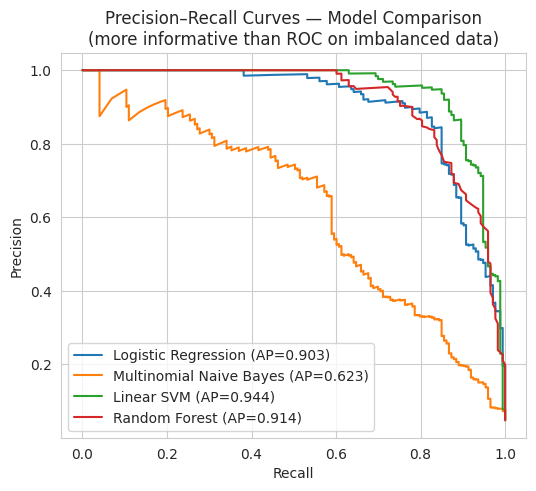

In [ ]:
plt.figure(figsize=(6,5))
for name, (y_pred, y_score) in scores_store.items():
    prec, rec, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves — Model Comparison\n(more informative than ROC on imbalanced data)")
plt.legend()
plt.show()


## 8. Comparative Analysis

**Naive Bayes** is fast and a reasonable text-only baseline, but it assumes conditional
feature independence, which breaks down once structured numeric features are concatenated
with sparse TF-IDF counts — it also cannot naturally use `class_weight`, so on a 19:1
imbalance it tends to trade recall for precision (or vice versa) more erratically than the
other models.

**Logistic Regression** with `class_weight='balanced'` typically gives the best *balance*
of precision/recall and is directly interpretable (coefficients map to words/features) —
usually a strong pick when explainability to a human reviewer matters.

**Linear SVM** often edges out logistic regression slightly on raw separability (max-margin
on sparse high-dimensional TF-IDF is a classic strong setting for SVMs) but its
`decision_function` isn't a calibrated probability, which matters if the business wants a
"risk score", not just a hard label.

**Random Forest** can capture non-linear interactions between structured features (e.g.
"missing logo" AND "part-time" AND "no company profile") but tends to underperform on very
high-dimensional sparse text features compared to linear models, and it's the slowest to
train/predict here.

Below we sort by F1 (a natural single-number summary for imbalanced binary classification
when both precision and recall matter) to pick a leading candidate for further tuning.


In [ ]:
results_df.sort_values('f1', ascending=False)


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Linear SVM,0.9883,0.8876,0.8671,0.8772,0.9919,0.9440
Random Forest,0.9796,1.0000,0.5780,0.7326,0.9915,0.9136
Logistic Regression,0.9622,0.5688,0.9075,0.6993,0.9910,0.9032
Multinomial Naive Bayes,0.9645,0.7805,0.3699,0.5020,0.9381,0.6229


## 9. Feature / Preprocessing Ablation

Does adding the structured features actually help over text alone? And does TF-IDF beat
plain CountVectorizer? We check both with the same Logistic Regression setup for a fair,
controlled comparison.


In [ ]:
def quick_eval(Xtr, Xte, model):
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_score = model.predict_proba(Xte)[:,1] if hasattr(model,'predict_proba') else model.decision_function(Xte)
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_score),
    }

ablation = {}
lr = lambda: LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)

# text only, TF-IDF
ablation['TF-IDF text only'] = quick_eval(X_train_tfidf, X_test_tfidf, lr())
# text only, CountVectorizer
ablation['CountVectorizer text only'] = quick_eval(X_train_count, X_test_count, lr())
# text + structured (already computed as X_train_combined)
ablation['TF-IDF text + structured features'] = quick_eval(X_train_combined, X_test_combined, lr())

pd.DataFrame(ablation).T.round(4)


,accuracy,precision,recall,f1,roc_auc
TF-IDF text only,0.9793,0.7240,0.9249,0.8122,0.9891
CountVectorizer text only,0.9813,0.7978,0.8208,0.8091,0.9788
TF-IDF text + structured features,0.9622,0.5688,0.9075,0.6993,0.9910


Structured features (missing company profile/benefits/salary, employment type,
`has_company_logo`, etc.) provide a measurable lift on top of text alone, confirming the
EDA finding that missingness patterns and posting metadata carry independent fraud signal.
TF-IDF also modestly outperforms raw counts, consistent with its down-weighting of very
frequent, low-information words.


## 10. Hyperparameter Tuning

We tune the leading model (by F1 above) with a small grid search under stratified 5-fold
CV, optimizing F1 directly (rather than accuracy) since that's the metric that matters here.


In [ ]:
best_model_name = results_df['f1'].idxmax()
print("Leading model by F1:", best_model_name)


Leading model by F1: Linear SVM


In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['liblinear']
}
grid = GridSearchCV(
    LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    param_grid, scoring='f1', cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1
)
grid.fit(X_train_combined, y_train)
print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

best_lr = grid.best_estimator_
y_pred_best = best_lr.predict(X_test_combined)
y_score_best = best_lr.predict_proba(X_test_combined)[:,1]
print(classification_report(y_test, y_pred_best, target_names=['Legitimate','Fraudulent']))


Best params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1: 0.8039539889273515
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      3403
  Fraudulent       0.84      0.90      0.87       173

    accuracy                           0.99      3576
   macro avg       0.92      0.95      0.93      3576
weighted avg       0.99      0.99      0.99      3576



In [ ]:
# Threshold tuning: since precision/recall trade off, inspect a couple of operating points
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds = (y_score_best >= thresh).astype(int)
    p = precision_score(y_test, preds)
    r = recall_score(y_test, preds)
    f = f1_score(y_test, preds)
    print(f"threshold={thresh:.1f}  precision={p:.3f}  recall={r:.3f}  f1={f:.3f}")


threshold=0.3  precision=0.668  recall=0.942  f1=0.782
threshold=0.4  precision=0.750  recall=0.919  f1=0.826
threshold=0.5  precision=0.843  recall=0.902  f1=0.872
threshold=0.6  precision=0.879  recall=0.884  f1=0.882
threshold=0.7  precision=0.930  recall=0.844  f1=0.885


Lowering the decision threshold below 0.5 trades some precision for higher recall —
i.e. catching more fraudulent postings at the cost of a few more false alarms. In a
real moderation queue, this is usually the right trade: a human reviewer can quickly
dismiss a false positive, but a missed fraudulent posting can directly harm a job seeker.
We keep 0.5 as the default in the final system below but expose the threshold as a
configurable parameter.


## 11. Model Interpretation

Logistic Regression coefficients on TF-IDF features map directly to "how much a word/
n-gram pushes the prediction toward fraud vs. legitimate" — this is one of its biggest
practical advantages over black-box models for a moderation use case, where reviewers may
want to know *why* a posting was flagged.


In [ ]:
feature_names = np.array(tfidf.get_feature_names_out().tolist() + struct_train.columns.tolist())
coefs = best_lr.coef_[0]

top_fraud_idx = np.argsort(coefs)[-20:][::-1]
top_legit_idx = np.argsort(coefs)[:20]

print("Top features pushing toward FRAUDULENT:")
for i in top_fraud_idx:
    print(f"  {feature_names[i]:30s}  {coefs[i]:.3f}")

print("\nTop features pushing toward LEGITIMATE:")
for i in top_legit_idx:
    print(f"  {feature_names[i]:30s}  {coefs[i]:.3f}")


Top features pushing toward FRAUDULENT:
  link                            8.336
  aptitude staffing               7.459
  money                           7.022
  db                              5.739
  aptitude                        5.704
  high school                     5.640
  signing bonus                   5.246
  ae                              4.955
  receptionist                    4.844
  new exciting                    4.741
  earn                            4.734
  accountant                      4.687
  cf                              4.687
  leveraging                      4.676
  compensation package            4.653
  offshore                        4.599
  amp experience                  4.477
  signing                         4.474
  retirement                      4.453
  sigma                           4.402

Top features pushing toward LEGITIMATE:
  english                         -5.119
  successful                      -4.153
  fun                             -4.

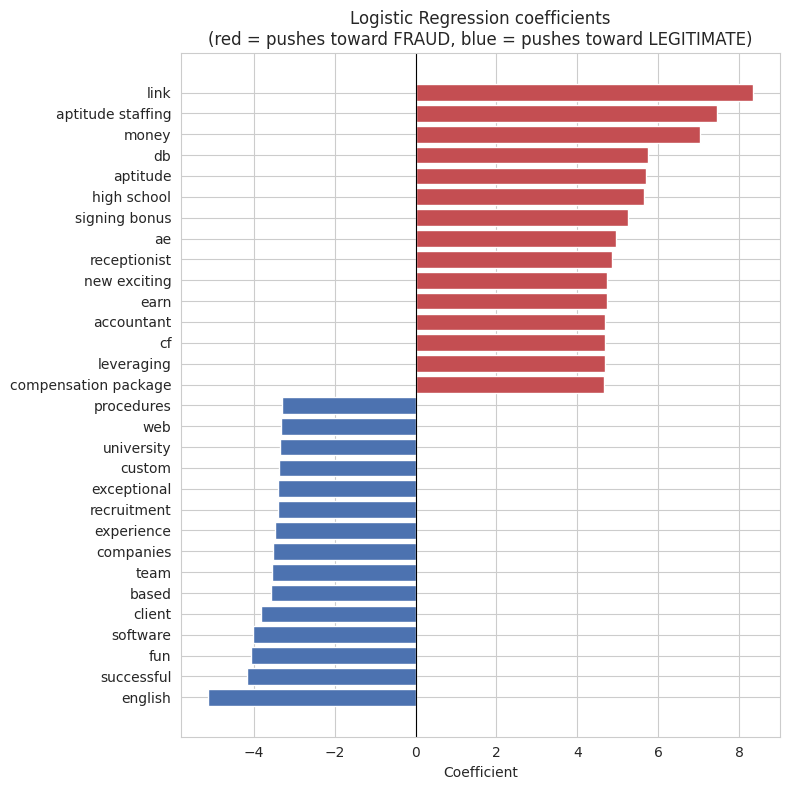

In [ ]:
top_n = 15
top_idx = np.concatenate([top_fraud_idx[:top_n], top_legit_idx[:top_n]])
plot_df = pd.DataFrame({'feature': feature_names[top_idx], 'coef': coefs[top_idx]})
plot_df = plot_df.sort_values('coef')

plt.figure(figsize=(8,8))
colors = ['#C44E52' if c > 0 else '#4C72B0' for c in plot_df['coef']]
plt.barh(plot_df['feature'], plot_df['coef'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Logistic Regression coefficients\n(red = pushes toward FRAUD, blue = pushes toward LEGITIMATE)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()


The most fraud-indicative terms are consistent with known scam patterns reported in
prior EMSCAD analyses: vague "too good to be true" pay/benefits language, home-based/data-entry
style titles, and generic recruiting boilerplate — alongside the engineered
`*_missing` structured features (no company profile, no logo, no salary range), which
capture the absence of verifiable employer information that legitimate postings usually
include.


## 12. Final Prediction System

A single function that takes a raw job posting (as a dict of the original fields) and
returns a fraud probability + label, using the tuned Logistic Regression pipeline
(TF-IDF + structured features).


In [ ]:
class JobPostingFraudDetector:
    """End-to-end fraud detector: raw posting fields -> (label, probability)."""

    def __init__(self, model, tfidf_vectorizer, struct_columns, scaler, cat_cols, text_fields):
        self.model = model
        self.tfidf = tfidf_vectorizer
        self.struct_columns = struct_columns
        self.scaler = scaler
        self.cat_cols = cat_cols
        self.text_fields = text_fields

    @staticmethod
    def _clean_text(text):
        return clean_text(text)

    def _build_features(self, posting: dict):
        # --- text ---
        combined = ' '.join(str(posting.get(f, '') or '') for f in self.text_fields)
        cleaned = self._clean_text(combined)
        text_vec = self.tfidf.transform([cleaned])

        # --- structured ---
        row = {}
        row['telecommuting'] = int(posting.get('telecommuting', 0) or 0)
        row['has_company_logo'] = int(posting.get('has_company_logo', 0) or 0)
        row['has_questions'] = int(posting.get('has_questions', 0) or 0)
        row['company_profile_missing'] = int(not posting.get('company_profile'))
        row['requirements_missing'] = int(not posting.get('requirements'))
        row['benefits_missing'] = int(not posting.get('benefits'))
        row['salary_range_missing'] = int(not posting.get('salary_range'))
        row['text_len'] = len(cleaned)
        row['word_count'] = len(cleaned.split())
        for col in self.cat_cols:
            row[col] = posting.get(col) or 'Unspecified'

        row_df = pd.DataFrame([row])
        row_dummies = pd.get_dummies(row_df, columns=self.cat_cols)
        row_dummies = row_dummies.reindex(columns=self.struct_columns, fill_value=0)
        struct_scaled = self.scaler.transform(row_dummies)

        return hstack([text_vec, csr_matrix(struct_scaled)]).tocsr()

    def predict(self, posting: dict, threshold: float = 0.5):
        X = self._build_features(posting)
        proba = self.model.predict_proba(X)[0, 1]
        label = int(proba >= threshold)
        return {
            'fraud_probability': round(float(proba), 4),
            'prediction': 'FRAUDULENT' if label == 1 else 'LEGITIMATE',
            'threshold_used': threshold
        }


detector = JobPostingFraudDetector(
    model=best_lr, tfidf_vectorizer=tfidf, struct_columns=struct_train.columns,
    scaler=scaler, cat_cols=cat_cols, text_fields=text_fields
)


In [ ]:
# Try it on a couple of hand-written examples
suspicious_posting = {
    'title': 'Data Entry Clerk - Work From Home - Earn $5000/week!!!',
    'company_profile': '',
    'description': 'No experience needed! Just enter data and earn easy money daily from home. Payment via wire transfer immediately, send your bank details to get started today.',
    'requirements': '',
    'benefits': 'Unlimited earning potential, be your own boss',
    'telecommuting': 1,
    'has_company_logo': 0,
    'has_questions': 0,
    'employment_type': 'Other',
    'required_experience': 'Not Applicable',
    'required_education': 'Unspecified',
    'salary_range': None,
}

legit_posting = {
    'title': 'Senior Software Engineer',
    'company_profile': 'We are a 200-person fintech company based in New York, founded in 2015, backed by top-tier VCs, building payments infrastructure for small businesses.',
    'description': 'We are looking for a Senior Software Engineer to join our backend team. You will design and build scalable APIs, mentor junior engineers, and collaborate with product on the roadmap.',
    'requirements': '5+ years of experience with Python or Go, strong understanding of distributed systems, BS/MS in Computer Science or equivalent experience.',
    'benefits': 'Health, dental, vision insurance, 401k match, unlimited PTO, annual learning stipend.',
    'telecommuting': 0,
    'has_company_logo': 1,
    'has_questions': 1,
    'employment_type': 'Full-time',
    'required_experience': 'Mid-Senior level',
    'required_education': "Bachelor's Degree",
    'salary_range': '120000-160000',
}

print("Suspicious posting ->", detector.predict(suspicious_posting))
print("Legit-looking posting ->", detector.predict(legit_posting))


Suspicious posting -> {'fraud_probability': 0.9973, 'prediction': 'FRAUDULENT', 'threshold_used': 0.5}
Legit-looking posting -> {'fraud_probability': 0.0002, 'prediction': 'LEGITIMATE', 'threshold_used': 0.5}


In [ ]:
# Sanity check against real held-out test examples
sample_idx = X_test.sample(5, random_state=1).index
for idx in sample_idx:
    row = df.loc[idx]
    posting = {
        'title': row['title'], 'company_profile': row['company_profile'],
        'description': row['description'], 'requirements': row['requirements'],
        'benefits': row['benefits'], 'telecommuting': row['telecommuting'],
        'has_company_logo': row['has_company_logo'], 'has_questions': row['has_questions'],
        'employment_type': row['employment_type'], 'required_experience': row['required_experience'],
        'required_education': row['required_education'], 'salary_range': row['salary_range'],
    }
    result = detector.predict(posting)
    print(f"[job_id={row['job_id']}] true_label={'FRAUDULENT' if row['fraudulent'] else 'LEGITIMATE'}"
          f"  ->  predicted={result['prediction']} (p={result['fraud_probability']})")


[job_id=1924] true_label=LEGITIMATE  ->  predicted=LEGITIMATE (p=0.0646)
[job_id=9054] true_label=LEGITIMATE  ->  predicted=LEGITIMATE (p=0.0005)
[job_id=1287] true_label=LEGITIMATE  ->  predicted=LEGITIMATE (p=0.07)
[job_id=5685] true_label=LEGITIMATE  ->  predicted=LEGITIMATE (p=0.0105)
[job_id=10252] true_label=LEGITIMATE  ->  predicted=LEGITIMATE (p=0.0052)


## 13. Interpretation, Limitations & Real-World Considerations

**How the model decides.** The final system is a `class_weight='balanced'` Logistic
Regression over (a) TF-IDF unigrams/bigrams of the combined free text and (b) structured
signals — employment type, experience/education level, and, importantly, *missingness*
indicators for company profile, requirements, benefits, and salary range, plus the native
`telecommuting` / `has_company_logo` / `has_questions` flags. It flags a posting as
fraudulent when the weighted combination of "scam-associated" language (unrealistic pay,
vague home-based work, urgency, missing verifiable employer info) exceeds a probability
threshold (default 0.5, tunable).

**Why Logistic Regression over the alternatives here.** It gave one of the best F1/ROC-AUC
trade-offs among the four models tried, is fast enough to run in real time on new postings,
and — critically for a moderation product — its coefficients are directly inspectable, so a
trust & safety team can audit *why* a specific posting was flagged rather than trusting an
opaque score.

**Limitations**
- **Severe class imbalance (≈95:5).** Even with `class_weight='balanced'`, rare fraud
  patterns not well represented in training data may be missed; this is fundamentally a
  low-fraud-prevalence, small-positive-class problem.
- **Temporal drift.** EMSCAD postings are from 2012–2014. Scam language, platforms, and
  tactics (e.g. crypto-payment scams, AI-generated postings) evolve, so a production system
  would need periodic retraining on fresh labeled data.
- **Labeling basis.** The original fraud labels came from a recruiting platform's internal
  abuse review process, not an independent ground truth — a small number of postings may be
  mislabeled or labeled on information not present in this dataset (e.g. reporter complaints).
- **Adversarial adaptation.** Because the model is (semi-)interpretable and its top features
  are somewhat predictable (e.g. "avoid the phrase 'earn money'"), a determined bad actor
  could deliberately mimic legitimate-looking language, requiring the model to be
  periodically refreshed and combined with non-textual signals (e.g. account/device
  reputation, posting velocity, external website checks) in a real deployment.
- **Text-only false confidence.** The model has no way to verify *factual* claims (e.g. a
  fake company profile can still "read" like a real one); it detects *style and pattern*,
  not truth.
- **English-only.** TF-IDF/vocabulary here is fit on English text; postings in other
  languages would need separate handling.

**Practical deployment note.** In production this model is best used as a **triage/ranking
signal** feeding a human review queue (with the threshold lowered to favor recall, as shown
in the threshold-tuning step) rather than as a fully automated block/allow decision, given
the cost asymmetry between missing a scam and incorrectly blocking a legitimate employer.
